# Лабораторная работа № 3

## Пакет matplotlib

Выполнил: Юрков Владимир  
Группа: МО-42.2

Цель работы: изучить основные способы визуализации данных с помощью библиотеки matplotlib.

## Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
df = df.dropna(how="all").dropna(axis=1, how="all")
df = df.replace(-200, np.nan)
df.head()

Matplotlib is building the font cache; this may take a moment.


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Задание 1

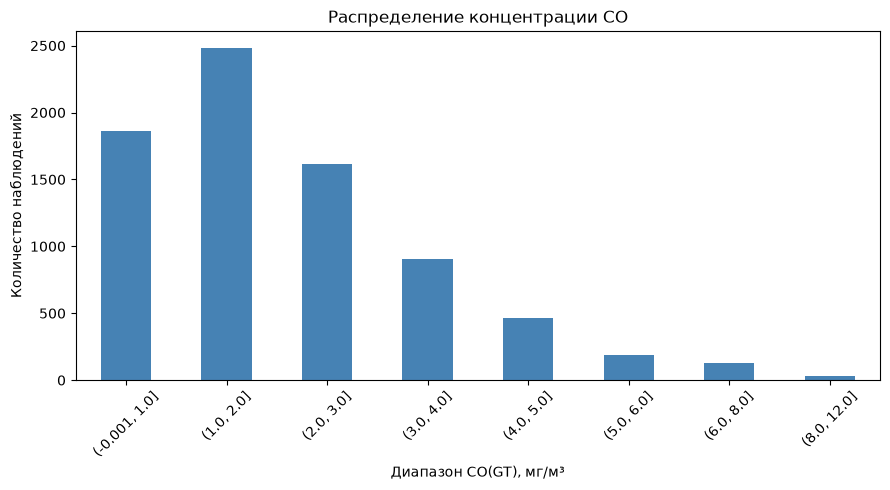

CO(GT)
(-0.001, 1.0]    1861
(1.0, 2.0]       2485
(2.0, 3.0]       1613
(3.0, 4.0]        903
(4.0, 5.0]        468
(5.0, 6.0]        187
(6.0, 8.0]        127
(8.0, 12.0]        30
Name: count, dtype: int64

In [2]:
co_ranges = pd.cut(
    df["CO(GT)"],
    bins=[0, 1, 2, 3, 4, 5, 6, 8, 12],
    include_lowest=True
)
co_counts = co_ranges.value_counts().sort_index()

co_counts.plot(kind="bar", color="steelblue", figsize=(9, 5))
plt.title("Распределение концентрации CO")
plt.xlabel("Диапазон CO(GT), мг/м³")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

co_counts

## Задание 2

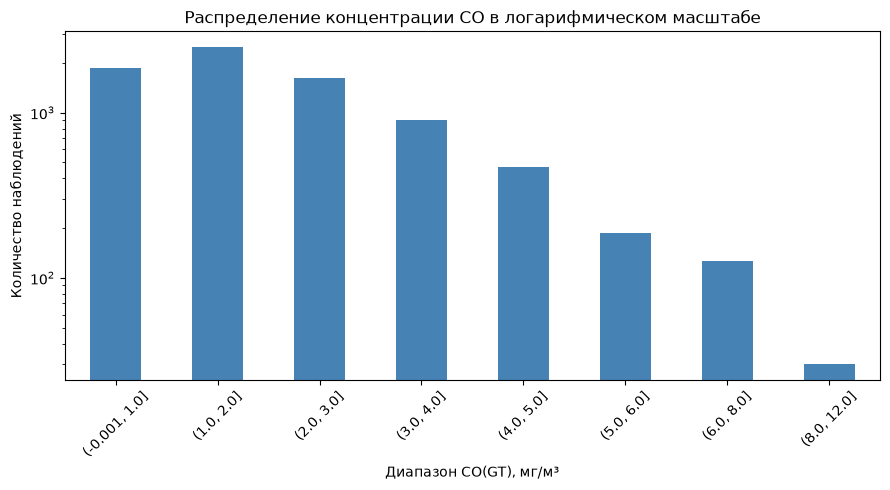

In [3]:
co_counts.plot(kind="bar", color="steelblue", figsize=(9, 5), logy=True)
plt.title("Распределение концентрации CO в логарифмическом масштабе")
plt.xlabel("Диапазон CO(GT), мг/м³")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Задание 3

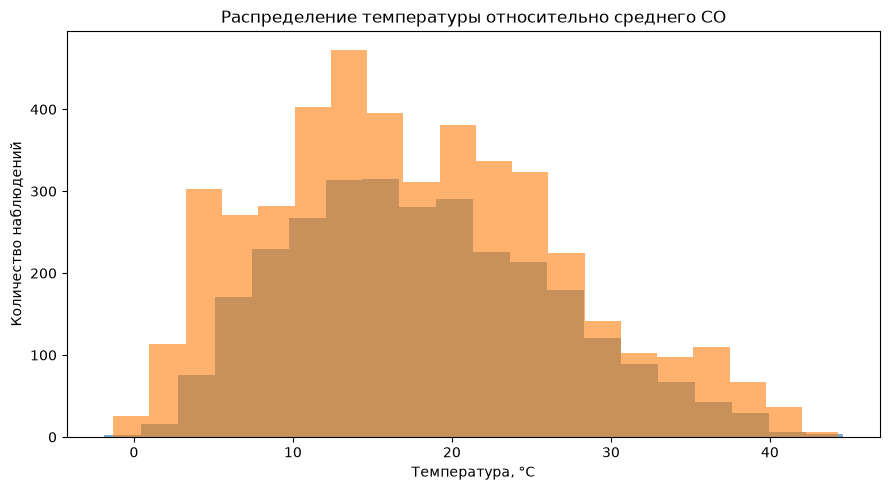

In [4]:
mean_co = df["CO(GT)"].mean()
temperature_above = df.loc[df["CO(GT)"] > mean_co, "T"].dropna()
temperature_below = df.loc[df["CO(GT)"] < mean_co, "T"].dropna()

plt.figure(figsize=(9, 5))
plt.hist(temperature_above, bins=20, alpha=0.6)
plt.hist(temperature_below, bins=20, alpha=0.6)
plt.title("Распределение температуры относительно среднего CO")
plt.xlabel("Температура, °C")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

## Задание 4

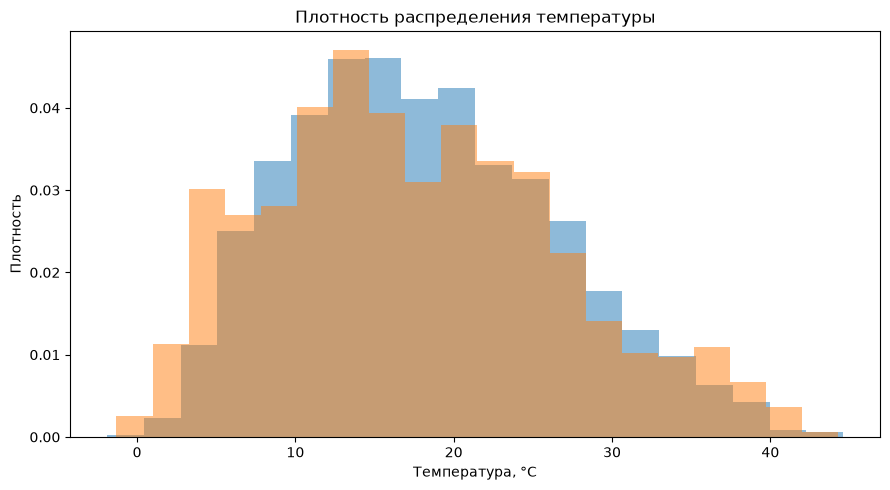

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(temperature_above, bins=20, density=True, alpha=0.5)
plt.hist(temperature_below, bins=20, density=True, alpha=0.5)
plt.title("Плотность распределения температуры")
plt.xlabel("Температура, °C")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()

## Задание 5

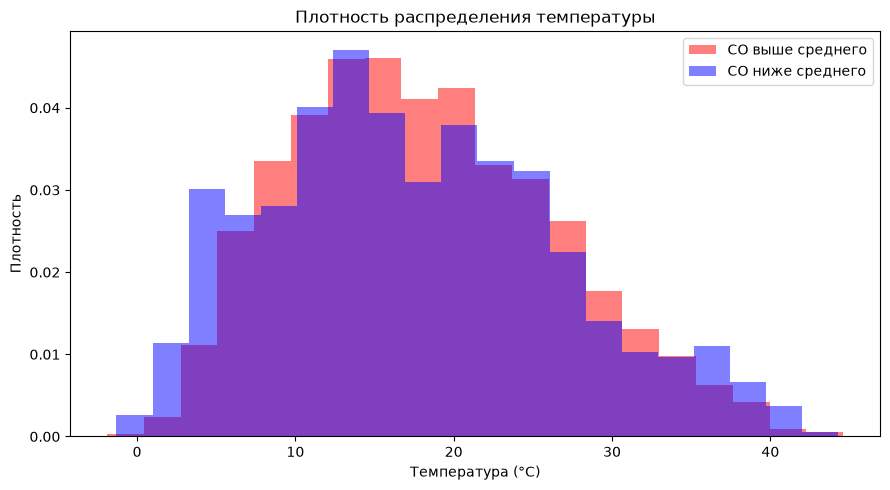

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(
    temperature_above,
    bins=20,
    density=True,
    alpha=0.5,
    color="red",
    label="CO выше среднего"
)
plt.hist(
    temperature_below,
    bins=20,
    density=True,
    alpha=0.5,
    color="blue",
    label="CO ниже среднего"
)
plt.title("Плотность распределения температуры")
plt.xlabel("Температура (°C)")
plt.ylabel("Плотность")
plt.legend()
plt.tight_layout()
plt.show()

## Задание 6

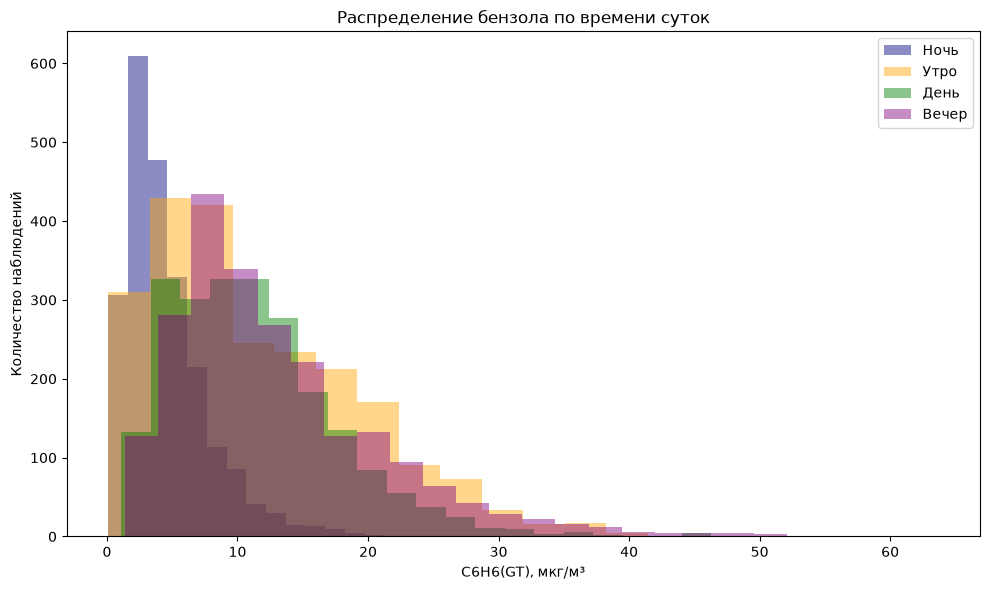

In [7]:
df["Час"] = df["Time"].str.split(".").str[0].astype(int)
df["Время суток"] = pd.cut(
    df["Час"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Ночь", "Утро", "День", "Вечер"]
)

colors = ["navy", "orange", "green", "purple"]
plt.figure(figsize=(10, 6))

for period, color in zip(["Ночь", "Утро", "День", "Вечер"], colors):
    values = df.loc[df["Время суток"] == period, "C6H6(GT)"].dropna()
    plt.hist(values, bins=20, alpha=0.45, color=color, label=period)

plt.title("Распределение бензола по времени суток")
plt.xlabel("C6H6(GT), мкг/м³")
plt.ylabel("Количество наблюдений")
plt.legend()
plt.tight_layout()
plt.show()

## Задание 7

<Figure size 900x500 with 0 Axes>

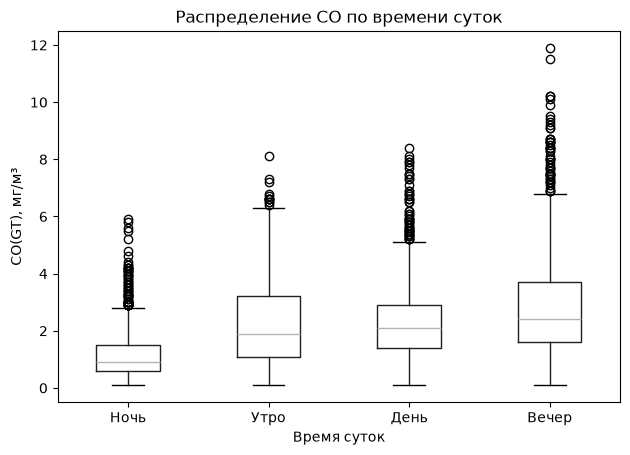

In [8]:
plt.figure(figsize=(9, 5))
df.boxplot(column="CO(GT)", by="Время суток", grid=False)
plt.title("Распределение CO по времени суток")
plt.suptitle("")
plt.xlabel("Время суток")
plt.ylabel("CO(GT), мг/м³")
plt.tight_layout()
plt.show()

## Задание 8

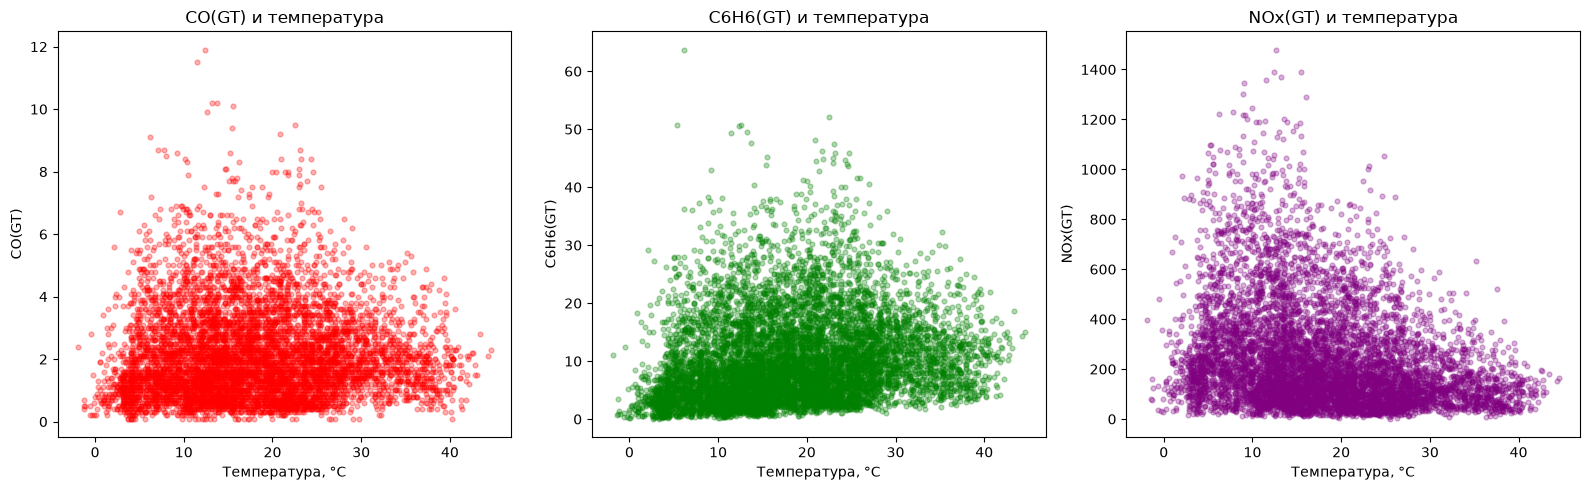

In [9]:
substances = ["CO(GT)", "C6H6(GT)", "NOx(GT)"]
colors = ["red", "green", "purple"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, column, color in zip(axes, substances, colors):
    ax.scatter(df["T"], df[column], color=color, alpha=0.3, s=12)
    ax.set_title(f"{column} и температура")
    ax.set_xlabel("Температура, °C")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

## Задание 9*

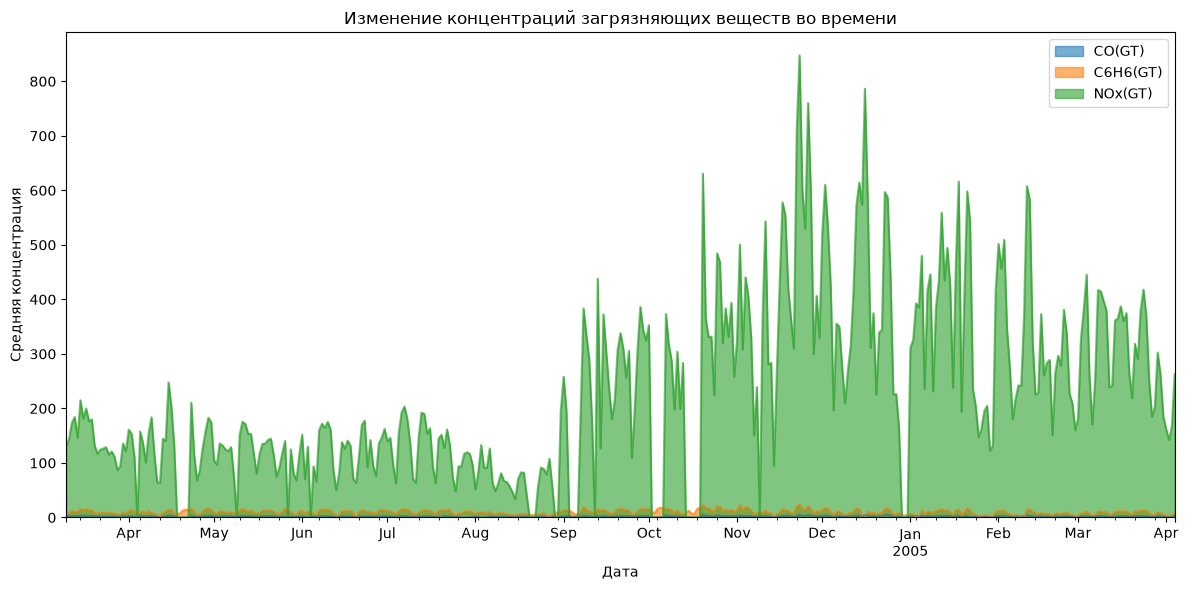

In [10]:
df["Дата и время"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S"
)

daily_data = (
    df.set_index("Дата и время")[["CO(GT)", "C6H6(GT)", "NOx(GT)"]]
    .resample("D")
    .mean()
)

daily_data.plot.area(figsize=(12, 6), alpha=0.6, stacked=False)
plt.title("Изменение концентраций загрязняющих веществ во времени")
plt.xlabel("Дата")
plt.ylabel("Средняя концентрация")
plt.tight_layout()
plt.show()

## Вывод

В ходе работы были построены столбчатые диаграммы, гистограммы, boxplot, диаграммы рассеяния и график с областями. Визуализация показала распределение загрязняющих веществ, различия по времени суток и связь показателей с температурой.

Ссылка на репозиторий с кодом решения: https://github.com/VovanGod/MO/tree/main/%D0%9B%D0%A03